# Colorization Environment Demo

This notebook demonstrates the Colorization environment where you adjust hue and saturation to match a target color.

In [3]:
import gymnasium as gym
import numpy as np
from IPython.display import display
from PIL import Image

## 1. Create and Inspect Environment (Easy)

In [4]:
env = gym.make("colorization/easy", seed=42)
print(f"Action Space: {env.action_space}")
print(f"Available actions: {env.action_space.get_function_names()}")
print(f"Observation Space: {env.observation_space}")

Action Space: FuncConditional(['rotate', 'saturate', 'stop'])
Available actions: ['rotate', 'saturate', 'stop']
Observation Space: None


## 2. Reset and View Initial State

Observation shape: (336, 595, 3)
Info: {}


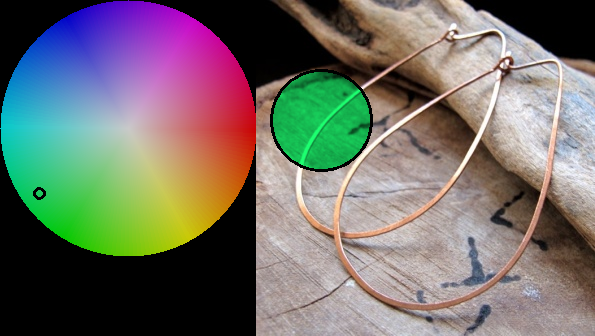


Task Prompt:
You are performing a color-matching task. You see two images side by side:
- LEFT: A color wheel showing your current hue and saturation selection
- RIGHT: An image with a circular region colored with your current selection (gray outside the circle)

Your goal is to adjust the hue and saturation to match the original color that appears at the center of the circular region in the right image. The circle's border shows the exact target location.

Success criteria: You succeed when your color selection closely matches the target color in both hue and saturation.

Available actions:
1. 'rotate': Adjust the hue by rotating around the color wheel (circular motion). Format: `('rotate', angle)` where angle is an integer between -360 and 360 degrees.
2. 'saturate': Adjust the saturation by moving toward or away from the center of the wheel. Format: `('saturate', delta)` where delta is an integer between -255 and 255.
3. 'stop': Submit your final color choice when you're satisfied 

In [5]:
obs, info = env.reset()
print(f"Observation shape: {obs.shape}")
print(f"Info: {info}")

# Display initial state
display(Image.fromarray(obs))
print(f"\nTask Prompt:\n{env.get_prompt()}")

## 3. Test Manual Actions

Action: ('rotate', 30)
Reward: 0.0, Terminated: False
Hue error: 143.56, Sat error: 172.00
Feedback: Action executed successfully.


user/launch/current/gymnasium/spaces/box.py:423: UserWarning: WARN: Casting input x to numpy array.
  gym.logger.warn("Casting input x to numpy array.")


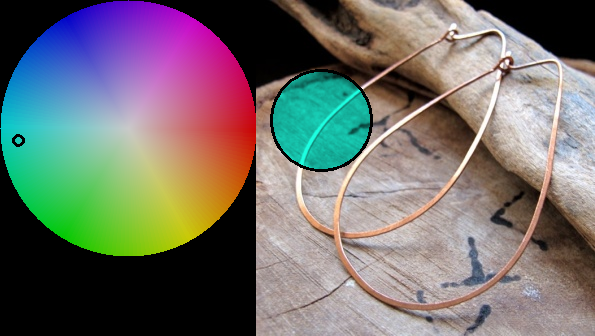

In [6]:
# Test rotating hue
action = "('rotate', 30)"
obs, reward, terminated, truncated, info = env.step(action)
print(f"Action: {action}")
print(f"Reward: {reward}, Terminated: {terminated}")
print(f"Hue error: {info['hue_error']:.2f}, Sat error: {info['sat_error']:.2f}")
print(f"Feedback: {info['env_feedback']}")
display(Image.fromarray(obs))

Action: ('saturate', 20)
Hue error: 143.56, Sat error: 192.00


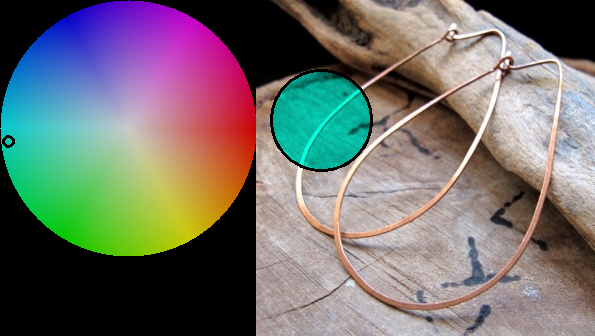

In [7]:
# Test adjusting saturation
action = "('saturate', 20)"
obs, reward, terminated, truncated, info = env.step(action)
print(f"Action: {action}")
print(f"Hue error: {info['hue_error']:.2f}, Sat error: {info['sat_error']:.2f}")
display(Image.fromarray(obs))

## 4. Test Solver (Easy Difficulty)

Initial state:


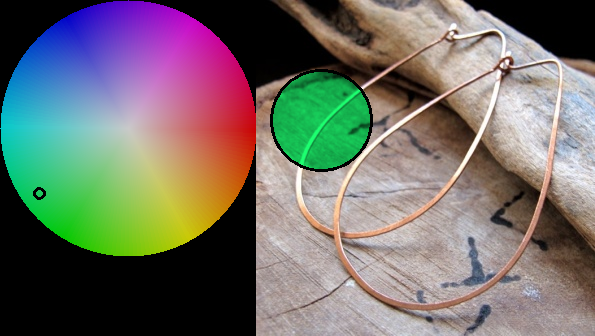


Solver generated 6 actions: ["('rotate', -37)", "('rotate', -74)", "('rotate', -3)"]...

Step 1: ('rotate', -37)
Hue error: 76.56, Sat error: 172.00


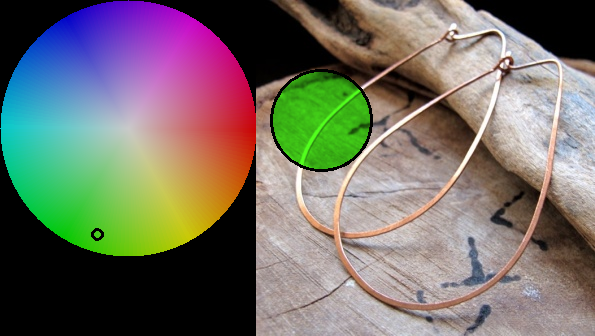


Step 2: ('rotate', -74)
Hue error: 2.56, Sat error: 172.00


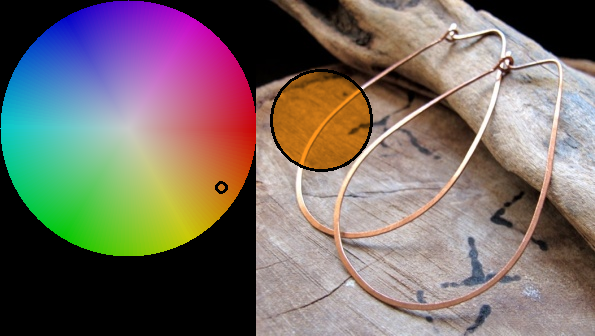


Step 3: ('rotate', -3)
Hue error: 0.44, Sat error: 172.00


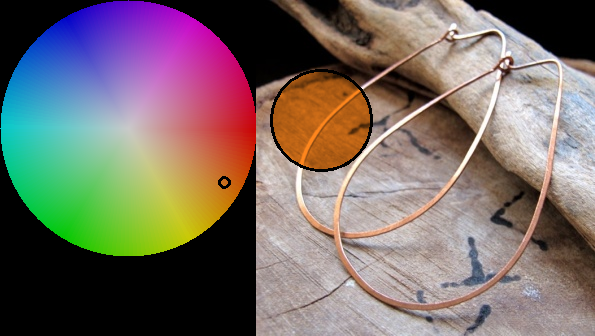


Step 6: ('stop', 'stop')
Hue error: 0.44, Sat error: 0.00


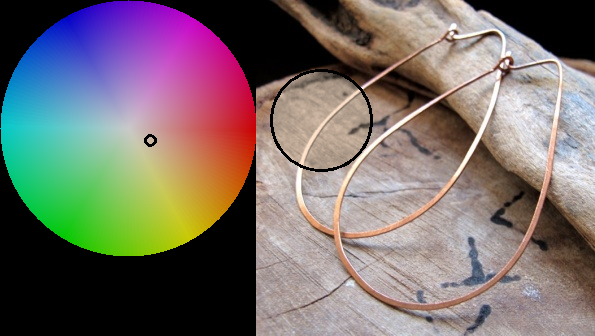


Episode finished! Reward: 1.0


In [8]:
# Reset environment
env = gym.make("colorization/easy", seed=42)
obs, info = env.reset()
print("Initial state:")
display(Image.fromarray(obs))

# Get solver actions
actions = env.solve(strategy="rotate", num_steps=5)
print(f"\nSolver generated {len(actions)} actions: {actions[:3]}...")

# Execute solver actions
for i, action in enumerate(actions):
    obs, reward, terminated, truncated, info = env.step(action)
    if i < 3 or terminated:  # Show first 3 and final
        print(f"\nStep {i+1}: {action}")
        print(f"Hue error: {info['hue_error']:.2f}, Sat error: {info['sat_error']:.2f}")
        display(Image.fromarray(obs))
    if terminated:
        print(f"\nEpisode finished! Reward: {reward}")
        break

env.close()

## 5. Test Hard Difficulty

Hard difficulty - smaller accuracy radius


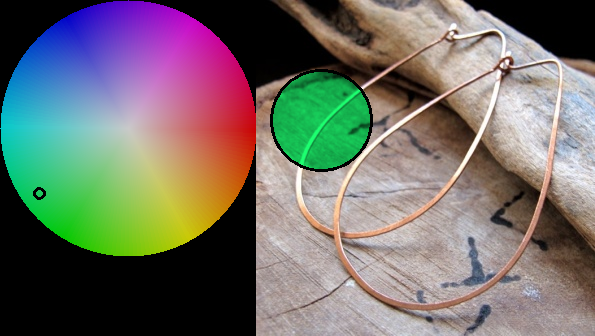

Final reward: 1.0
Color distance: 0.89, Threshold: 48.92


In [9]:
env_hard = gym.make("colorization/hard", seed=42)
obs, info = env_hard.reset()
print("Hard difficulty - smaller accuracy radius")
display(Image.fromarray(obs))

# Run solver
actions = env_hard.solve()
for action in actions:
    obs, reward, terminated, truncated, info = env_hard.step(action)
    if terminated:
        print(f"Final reward: {reward}")
        print(f"Color distance: {info['color_distance']:.2f}, Threshold: {info['threshold_distance']:.2f}")
        break

env_hard.close()